In [1]:
import torch
import warnings
warnings.filterwarnings("ignore")

In [2]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root="dataset", name="Cora")

data = dataset[0]

print(f"Dataset : {dataset}")
print(f"-------------------")
print(f"Number of graphs : {len(dataset)}")
print(f"Number of nodes : {dataset.x.shape[0]}")
print(f"Number of features: {dataset.num_features}")
print(f"Number of classes: {dataset.num_classes}")

print(f"\nGraph:")
print("----------")
print(f"Edges are directed: {data.is_directed()}")
print(f"Graph has isolated nodes: {data.has_isolated_nodes()}")
print(f"Graph has loops: {data.has_self_loops()}")

Dataset : Cora()
-------------------
Number of graphs : 1
Number of nodes : 2708
Number of features: 1433
Number of classes: 7

Graph:
----------
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: False


In [9]:
# Facebook Pasge dataset ==> Error로 이 실습에서 Facebook 데이터 관련 실습은 제외
from torch_geometric.datasets import FacebookPagePage

# dataset = FacebookPagePage(root="dataset") ==> HTTP Error 404 발생

dataset = FacebookPagePage(root="dataset")
data = dataset[0]

print(f"Dataset : {Dataset}")
print("----------------------")
print(f"Number of Graphs: {len(dataset)}")
print(f"Number of nodes: {data.x.shape[0]}")
print(f"Number of features: {dataset.num_features}")
print(f"Number of classes: {dataset.num_classes}")

print(f"\nGraph:")
print("----------")
print(f"Edges are directed: {data.is_directed()}")
print(f"Graph has isolated nodes: {data.has_isolated_nodes()}")
print(f"Graph has loops: {data.has_self_loops()}")

# create masks
data.train_mask = range(18000)
data.val_mask = range(18001,20000)
data.test_mask = range(20001, 22470)

HTTPError: HTTP Error 404: Not Found

In [3]:
# Cara dataset 을 DataFrame으로 변환
import pandas as pd

dataset = Planetoid(root="dataset", name="Cora")
data = dataset[0]

df_x = pd.DataFrame(data.x.numpy())
df_x["label"] = pd.DataFrame(data.y)
df_x

,0,1,2,3,4,5,6,7,8,9,...,1424,1425,1426,1427,1428,1429,1430,1431,1432,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2703,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2704,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2705,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2706,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3


In [4]:
# Torch MLP
# Pytorch MLP 모델을 구성하여 Classification 학습을 진행
import torch
# 랜덤시드 고정을 통해 동일한 결과가 나오도록 설정
torch.manual_seed(0)
from torch.nn import Linear
import torch.nn.functional as F

def accuracy(y_pred, y_true):
    return torch.sum(y_pred == y_true) / len(y_true)

class MLP(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.linear1 = Linear(dim_in, dim_h)
        self.linear2 = Linear(dim_h, dim_out)

    def forward(self, x):
        x = self.linear1(x)
        x = torch.relu(x)
        x = self.linear2(x)
        return F.log_softmax(x, dim=1)

    def fit(self, data, epochs):
        # 분류 문제에서는 CrossEntropyLoss loss function 사용
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(),lr=0.01, weight_decay=5e-4)
        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if (epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
                print(f"Epoch {epochs:>3} | Train Loss: {loss:.3f} | Train Acc:" f"{acc*100:>5.2f}% | Val Loss: {val_loss:.2f} |" f"Val Acc: {val_acc*100:.2f}%")

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x)
        acc = accuracy(out.argmax(dim=1)[data.test_mask],data.y[data.test_mask])
        return acc

# Create MLP model
mlp = MLP(dataset.num_features, 16, dataset.num_classes)
print(mlp)

# Train
mlp.fit(data, epochs=100)

# Test
acc = mlp.test(data)
print(f"\nMLP test accuracy: {acc*100:.2f}%")


MLP(
  (linear1): Linear(in_features=1433, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=7, bias=True)
)
Epoch 100 | Train Loss: 1.959 | Train Acc:14.29% | Val Loss: 2.00 |Val Acc: 12.40%
Epoch 100 | Train Loss: 0.110 | Train Acc:100.00% | Val Loss: 1.46 |Val Acc: 49.40%
Epoch 100 | Train Loss: 0.014 | Train Acc:100.00% | Val Loss: 1.44 |Val Acc: 51.00%
Epoch 100 | Train Loss: 0.008 | Train Acc:100.00% | Val Loss: 1.40 |Val Acc: 53.80%
Epoch 100 | Train Loss: 0.008 | Train Acc:100.00% | Val Loss: 1.37 |Val Acc: 55.40%
Epoch 100 | Train Loss: 0.009 | Train Acc:100.00% | Val Loss: 1.34 |Val Acc: 54.60%

MLP test accuracy: 53.40%


In [5]:
# VanillaGNN
class VanillaGNNLayer(torch.nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.linear = Linear(dim_in, dim_out, bias=False)

    def forward(self, x, adjacency):
        x = self.linear(x)
        x = torch.sparse.mm(adjacency, x)
        return x

In [7]:
from torch_geometric.utils import to_dense_adj

adjacency = to_dense_adj(data.edge_index)[0]
adjacency += torch.eye(len(adjacency))
adjacency

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 1.],
        [0., 0., 0.,  ..., 0., 1., 1.]])

In [9]:
# visualization function
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())
    
    plt.figure(figsize=(8,8))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

VanillaGNN(
  (gnn1): VanillaGNNLayer(
    (linear): Linear(in_features=1433, out_features=16, bias=False)
  )
  (gnn2): VanillaGNNLayer(
    (linear): Linear(in_features=16, out_features=7, bias=False)
  )
)
Epoch   0 | Train Loss: 2.381 | Train Acc: 7.86% | Val Loss: 2.16 |Val Acc: 18.80%
Epoch  20 | Train Loss: 0.100 | Train Acc:99.29% | Val Loss: 1.52 |Val Acc: 74.80%
Epoch  40 | Train Loss: 0.007 | Train Acc:100.00% | Val Loss: 2.29 |Val Acc: 74.00%
Epoch  60 | Train Loss: 0.002 | Train Acc:100.00% | Val Loss: 2.50 |Val Acc: 74.20%
Epoch  80 | Train Loss: 0.002 | Train Acc:100.00% | Val Loss: 2.50 |Val Acc: 74.00%
Epoch 100 | Train Loss: 0.002 | Train Acc:100.00% | Val Loss: 2.46 |Val Acc: 74.20%


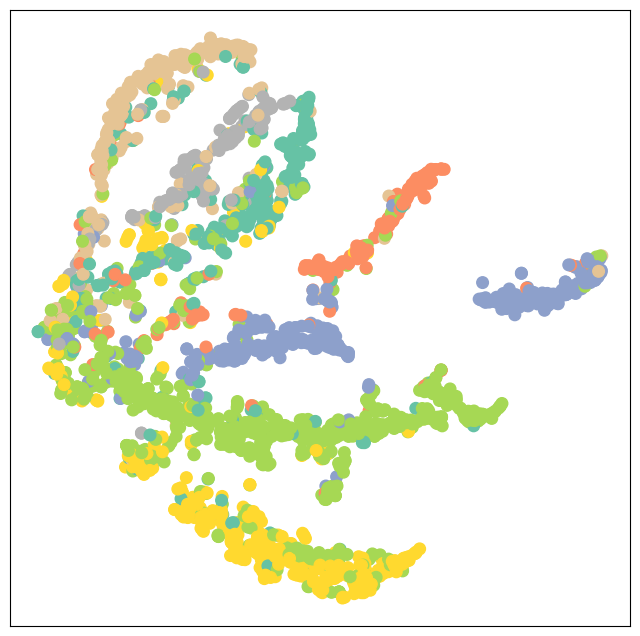


GNN test accuracy: 75.10%


In [11]:
class VanillaGNN(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gnn1 = VanillaGNNLayer(dim_in, dim_h)
        self.gnn2 = VanillaGNNLayer(dim_h, dim_out)

    def forward(self, x, adjacency):
        h = self.gnn1(x, adjacency)
        h = torch.relu(h)
        h = self.gnn2(h, adjacency)
        return F.log_softmax(h, dim=1)

    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=5e-4)
        self.train()

        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, adjacency)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
                print(f"Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:" f"{acc*100:>5.2f}% | Val Loss: {val_loss:.2f} |" f"Val Acc: {val_acc*100:.2f}%")

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, adjacency)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        visualize(out, color=data.y)
        return acc

gnn = VanillaGNN(dataset.num_features, 16, dataset.num_classes)
print(gnn)

gnn.fit(data, epochs=100)

acc = gnn.test(data)
print(f"\nGNN test accuracy: {acc*100:.2f}%")



## GCN